## Welfare Bot - Exploratory Data Analysis (EDA)

Tässä notebookissa tutkin Welfare Bot -hyvinvointidataa ennen koneoppimismallien käyttöä.

Tavoitteena on:
- ymmärtää datan rakennetta
- tarkistaa datan laatu
- analysoida hyvinvointimittareita
- visualisoida hyvinvoinnin muutoksia ajan yli

In [15]:
# kirjastojen lataaminen
import pandas as pd # pandas auttaa taulukkomuotoisen datan käsittelyssä
import numpy as np # numpy tarjoaa tehokkaita työkaluja numeeriseen laskentaan
import matplotlib.pyplot as plt # matplotlib auttaa datan visualisoinnissa


In [16]:
# datan lataaminen
data = pd.read_csv('../data/welfare_bot_metrics_missing.csv')



Datan tarkastelu ja esikäsittely

In [17]:
data.head() # näyttää datan ensimmäiset rivit, jotta voin tarkistaa, että tiedosto latautui oikein

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
0,2025-01-01,Aino Mäkinen,aino.makinen@demo.fi,4.40,3.94,2.99,1.00,0.88,3.38,8.89,low
1,2025-01-02,Aino Mäkinen,aino.makinen@demo.fi,4.83,4.31,2.66,0.96,0.86,3.27,8.98,low
2,2025-01-03,Aino Mäkinen,aino.makinen@demo.fi,4.30,3.24,2.28,0.80,0.82,3.66,7.67,low
3,2025-01-04,Aino Mäkinen,aino.makinen@demo.fi,3.84,3.44,3.00,NaN,0.91,2.79,NaN,NaN
4,2025-01-05,Aino Mäkinen,aino.makinen@demo.fi,3.99,4.05,2.46,0.94,0.85,3.36,8.25,low


In [18]:
data.tail() # näyttää datan viimeiset rivit, jotta voin tarkistaa, että tiedosto latautui oikein

,date,user_name,email,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score,risk_level
595,2025-05-26,Urho Leinonen,urho.leinonen@demo.fi,2.99,1.99,2.40,0.31,0.80,1.85,5.55,medium
596,2025-05-27,Urho Leinonen,urho.leinonen@demo.fi,NaN,1.19,2.06,0.12,NaN,2.37,NaN,NaN
597,2025-05-28,Urho Leinonen,urho.leinonen@demo.fi,3.87,0.94,2.32,0.08,0.84,1.24,5.05,high
598,2025-05-29,Urho Leinonen,urho.leinonen@demo.fi,3.60,1.26,2.62,0.36,1.00,0.96,5.82,medium
599,2025-05-30,Urho Leinonen,urho.leinonen@demo.fi,3.60,1.86,NaN,0.42,0.93,1.59,NaN,NaN


In [19]:
data.info() # antaa tietoa datan sarakkeista, kuten datatyypit ja mahdolliset puuttuvat arvot. 
            # tämä auttaa ymmärtämään datan rakennetta ja mahdollisia ongelmia, kuten puuttuvat tiedot.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              600 non-null    object 
 1   user_name         600 non-null    object 
 2   email             600 non-null    object 
 3   mood_score        555 non-null    float64
 4   sleep_score       567 non-null    float64
 5   food_score        561 non-null    float64
 6   hydration_score   543 non-null    float64
 7   medication_score  584 non-null    float64
 8   social_score      561 non-null    float64
 9   overall_score     398 non-null    float64
 10  risk_level        398 non-null    object 
dtypes: float64(7), object(4)
memory usage: 51.7+ KB


In [20]:
data.shape # näyttää datan rivien ja sarakkeiden määrän. Tämä auttaa ymmärtämään, kuinka laaja aineisto on. 
           # (rivien määrä, sarakkeiden määrä)

(600, 11)

In [21]:
data.columns # näyttää datan sarakkeiden nimet, jotta voin ymmärtää, mitä tietoja datassa on. 
             # tämä on tärkeää, jotta osaan viitata oikeisiin sarakkeisiin myöhemmissä vaiheissa. 

Index(['date', 'user_name', 'email', 'mood_score', 'sleep_score', 'food_score',
       'hydration_score', 'medication_score', 'social_score', 'overall_score',
       'risk_level'],
      dtype='object')

## Statistical analysis

In [22]:
data.describe() # antaa tilastollisen yhteenvedon numeerisista sarakkeista, kuten keskiarvo, mediaani, 
                # minimi, maksimi ja kvartiilit.

,mood_score,sleep_score,food_score,hydration_score,medication_score,social_score,overall_score
count,555.000000,567.000000,561.000000,543.000000,584.000000,561.000000,398.000000
mean,3.695910,3.526384,2.531319,0.742449,0.894212,2.411586,7.582362
std,0.562392,0.795803,0.439564,0.215266,0.072873,0.995882,0.981365
min,2.360000,0.660000,0.800000,0.000000,0.640000,0.000000,4.790000
25%,3.325000,3.125000,2.320000,0.620000,0.850000,1.750000,6.902500
50%,3.650000,3.670000,2.610000,0.790000,0.900000,2.370000,7.765000
75%,4.080000,4.090000,2.910000,0.910000,0.950000,3.050000,8.350000
max,5.000000,5.000000,3.000000,1.000000,1.000000,5.000000,9.630000


## Tilastollinen analyysi ja datan tarkastelu
Funktion avulla voidaan nähdä:
- havaintojen määrä (count')
- keskiarvo ('mean')
- keskihajonta ('std')
- minimi- ja maksimiarvot ('min', 'max)
- kvartiilit ('25%, '50%', '75%')

Tilastollinen analyysi auttaa ymmärtämään datan rakennetta ennen koneoppimismallin kouluttamista.

## Havaintojen määrä (count)

Analyysissä näkyi, että kaikissa sarakkeissa ei ollut yhtä paljon arvoja.

Esimerkiksi:
- 'mood_score' sisälsi 555 arvoa
- 'overall_score' sisälsi vain 398 arvoa

Tämä tarkoittaa, että osassa dataa oli puuttuvia arvoja.

## Keskiarvot (mean)

Keskiarvojen perusteella käyttäjien hyvinvointi oli yleisesti melko hyvä.

Esimerkiksi:
- 'overall_score' keskiarvo oli noin 7.58
- 'mood_score' keskiarvo oli noin 3.70
- 'sleep_score' keskiarvo oli noin 3.52

Tämä viittaa siihen, että suurin osa käyttäjistä voi keskimäärin melko hyvin.

## Keskihajonta (std)

Keskihajonta kuvaa sitä, kuinka paljon arvot vaihtelevat keskiarvon ympärillä.

Analyysissä näkyi, että erityisesti:
- uni (sleep_score')
- sosiaalinen aktiivisuus ('social_score)
- kokonaisvaltainen hyvinvointi ('overall_score')

vaihtelivat melko paljon.

Esimerkiksi:
- 'social_score' keskihajonta oli noin 0.99
- 'overall_score' keskihajonta oli noin 0.98

Tämä kertoo, että käyttäjien hyvinvointi ei ollut täysin tasaista, vaan datassa esiintyi normaalia vaihtelua ja ajoittaisia muutoksia.

Vaihtelu on tärkeää koneoppimisen kannalta, koska anomaly detection -mallit etsivät juuri normaalista käyttäytymisestä poikkeavia tilanteita.

## Minimiarvot (min)

Datan minimiarvoista näkyi, että osalla käyttäjistä esiintyi ajoittain heikompia hyvinvointiarvoja.

Esimerkiksi:
- 'sleep_score' minimi oli noin 0.66
- 'hydration_score' minimi oli 0
- 'social_score' minimi oli 0
- 'overall_score' minimi oli noin 4.79

Nämä arvot voivat viitata esimerkiksi:
- huonoon uneen
- vähäiseen nesteytykseen
- yksinäisyyteen
- yleiseen hyvinvoinnin heikkenemiseen

Tällaiset matalat arvot ovat erityisen kiinnostavia anomaly detection analyysissä, koska ne voivat kuvata mahdollisia riskitilanteita.

## Maksimiarvot (max)

Maksimiarvot osoittivat, että datassa esiintyi myös erittäin hyviä hyvinvointitilanteita.

Esimerkiksi:
- 'mood_scor' maksimi oli 5
- 'sleep_score' maksimi oli 5
- 'overall_score' maksimi oli noin 9.63

Tämä kertoo, että käyttäjien hyvinvointi vaihteli ajan myötä.

## Kvartiilit (25%, 50%, 75%)

Kvartiilit auttavat ymmärtämään datan jakaumaa.

- 25% kertoo alemman neljänneksen
- 50% kertoo mediaanin
- 75% kertoo ylemmän neljänneksen

Näiden avulla voidaan nähdä, missä suurin osa arvoista sijaitsee.

Esimerkiksi 'overall_score'-sarakkeessa:
- 25% arvoista oli alle noin 6.90
- mediaani oli noin 7.77
- 75% arvoista oli alle noin 8.35

Tämä kertoo, että suurin osa hyvinvointiarvoista sijoittui melko normaalille tasolle.

## Yhteenveto

Tilastollisen analyysin perusteella:
- datassa esiintyi normaalia vaihtelua
- käyttäjien hyvinvointi oli keskimäärin melko hyvä
- osassa arvoista näkyi ajoittaista heikkenemistä
- datassa oli puuttuvia arvoja
- aineisto soveltui hyvin anomaly detection -analyysiin

## Missing values analysis

In [23]:
data.isnull().sum() 
# tarkistan puuttuvat arvot jokaisessa sarakkeessa, koska puuttuvat arvot voivat vaikuttaa koneoppimismallin toimintaan.

date                  0
user_name             0
email                 0
mood_score           45
sleep_score          33
food_score           39
hydration_score      57
medication_score     16
social_score         39
overall_score       202
risk_level          202
dtype: int64

## Duplicate analysis

In [24]:
data.duplicated().sum() 
# tarkistan, onko datassa duplikaatteja, koska duplikaatit voivat vääristää mallin oppimista ja heikentää sen suorituskykyä.

np.int64(0)

## Datetime conversion

In [25]:
data["date"] = pd.to_datetime(data["date"]) 
# muutan "date" sarakkeen datetime-muotoon, jotta voin käyttää sitä aikaperusteisissa analyyseissä ja visualisoinneissa.

## Risk level visualization

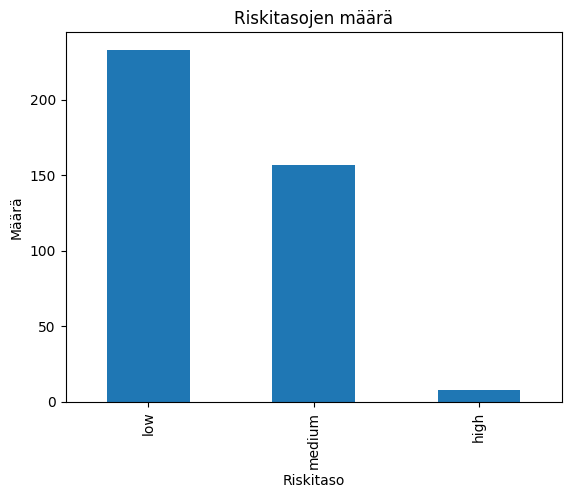

In [26]:
data["risk_level"].value_counts().plot(kind="bar") 
plt.title("Riskitasojen määrä")
plt.xlabel("Riskitaso")
plt.ylabel("Määrä")

plt.show()
# lasken riskitasojen esiintymismäärän ja teen siitä pylväsdiagrammin, jotta näen, kuinka monta kertaa kukin 
# riskitaso esiintyy datassa.

## Daily wellbeing trend

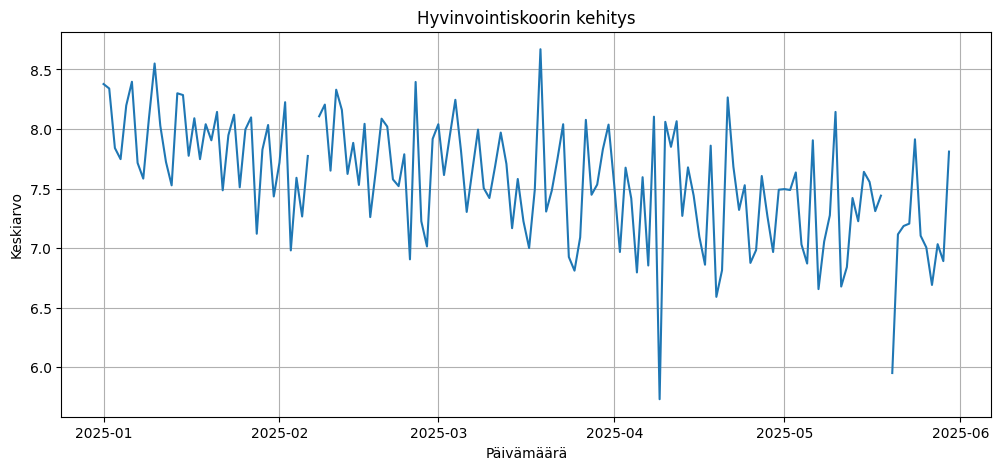

In [27]:
daily_score = data.groupby("date")["overall_score"].mean()

plt.figure(figsize=(12,5))

plt.plot(daily_score)

plt.title("Hyvinvointiskoorin kehitys")
plt.xlabel("Päivämäärä")
plt.ylabel("Keskiarvo")

plt.grid()

plt.show()
# ryhmittelen datan päivämäärän mukaan ja lasken kunkin päivän keskimääräisen hyvinvointiskoorin.
# sitten visualisoin hyvinvointiskoorin kehityksen ajan myötä, jottanäen, onko siinä selkeitä trendejä tai kausivaihteluita.    

## Havainnot visualisoinnista

Visualisoinnin perusteella hyvinvointiskoori vaihteli ajan myötä.
Suurimman osan ajasta keskimääräinen hyvinvointitaso pysyi melko vakaana noin välillä 7–8.
Datassa näkyi kuitenkin myös joitakin selkeitä laskuja ja nousuja eri ajankohtina.
Tämä kertoo, että käyttäjien hyvinvointi ei ollut täysin tasaista, vaan siinä esiintyi normaalia vaihtelua ajan myötä.

## Käyttäjän hyvinvointimittareiden visualisointi

Tässä vaiheessa visualisoin yhden käyttäjän tärkeimmät hyvinvointimittarit ajan yli.

Visualisoinnin avulla voidaan tarkastella:
- miten eri hyvinvointitekijät muuttuvat ajan myötä
- mitkä mittarit pysyvät vakaampina
- missä kohdissa hyvinvointi mahdollisesti heikkenee

Tarkastelen esimerkkinä käyttäjää "Aino Mäkinen".

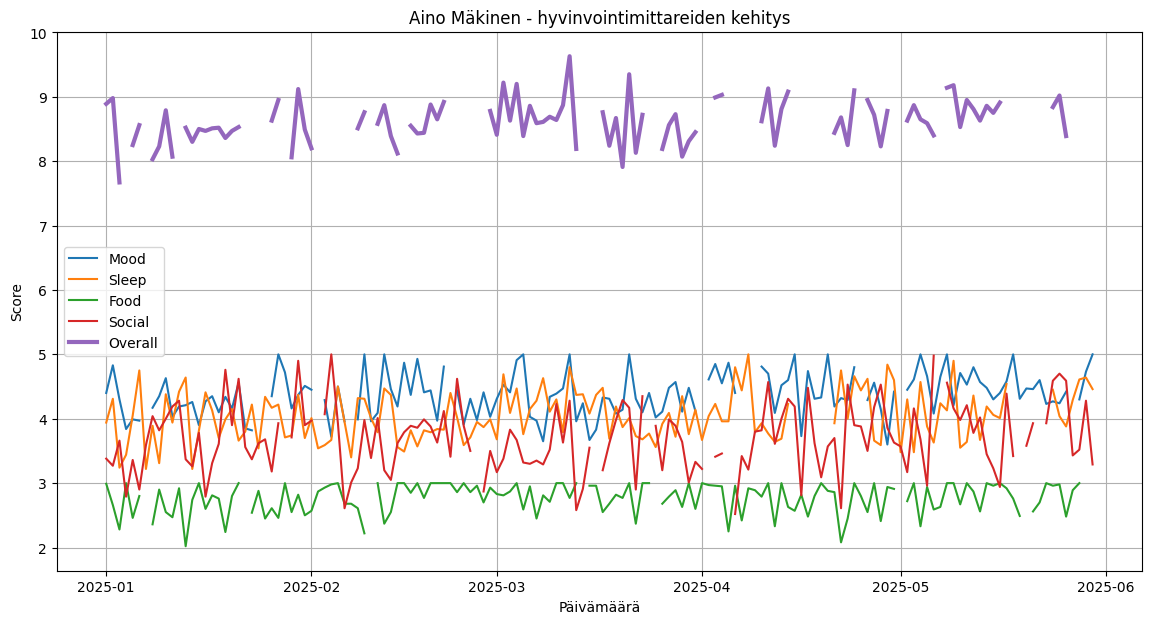

In [ ]:
# käyttäjän valinta
aino_data = data[data["user_name"] == "Aino Mäkinen"].copy()

# järjestetään päivämäärän mukaan
aino_data = aino_data.sort_values("date")

plt.figure(figsize=(14,7))

# mieliala
plt.plot(
    aino_data["date"],
    aino_data["mood_score"],
    label="Mood"
)

# uni
plt.plot(
    aino_data["date"],
    aino_data["sleep_score"],
    label="Sleep"
)

# ruokailu
plt.plot(
    aino_data["date"],
    aino_data["food_score"],
    label="Food"
)

# sosiaalinen aktiivisuus
plt.plot(
    aino_data["date"],
    aino_data["social_score"],
    label="Social"
)

# kokonaisvaltainen hyvinvointi
plt.plot(
    aino_data["date"],
    aino_data["overall_score"],
    label="Overall",
    linewidth=3
)

plt.title("Aino Mäkinen - hyvinvointimittareiden kehitys")

plt.xlabel("Päivämäärä")
plt.ylabel("Score")

plt.legend() # näyttää selitteen, jotta tiedän, mikä viiva edustaa mitäkin mittaria
plt.grid() # lisää ruudukon kuvaajaan, jotta lukeminen on helpompaa
plt.show() 

## Havainnot visualisoinnista

Visualisoinnissa näkyy myös katkoksia viivoissa.
Katkokset johtuvat puuttuvista arvoista (`NaN`) datassa. Tämä auttaa havaitsemaan, missä kohdissa hyvinvointitietoja ei ole saatavilla.
Puuttuvien arvojen tarkastelu on tärkeä osa data-analyysiä, koska koneoppimismallit eivät yleensä pysty käsittelemään tyhjiä arvoja ilman preprocessing vaihetta.
Tämän vuoksi puuttuvat arvot täytyy käsitellä myöhemmässä preprocessing-vaiheessa ennen koneoppimismallin kouluttamista.

# Yhteenveto

Tässä notebookissa analysoin Welfare Bot projektin hyvinvointidataa Exploratory Data Analysis (EDA) menetelmien avulla.

Analyysin aikana tarkastelin:
- datan rakennetta
- sarakkeiden tietotyyppejä
- puuttuvia arvoja
- hyvinvointimittareiden jakaumia
- käyttäjäkohtaisia hyvinvointimuutoksia
- hyvinvointiskoorin kehitystä ajan myötä

Analyysissä havaittiin, että datassa oli puuttuvia arvoja erityisesti sarakkeissa:
- overall_score
- risk_level
- hydration_score

Puuttuvien arvojen tarkastelu oli tärkeää, koska koneoppimismallit eivät yleensä pysty käsittelemään tyhjiä arvoja ilman preprocessing-vaihetta.

Visualisointien avulla oli mahdollista nähdä:
- hyvinvoinnin vaihtelua ajan myötä
- käyttäjien välisiä eroja
- mahdollisia hyvinvoinnin laskuja
- mittareiden välisiä yhteyksiä

EDA-vaihe auttoi ymmärtämään datan rakennetta ennen koneoppimismallien rakentamista.

Tämän analyysin perusteella data soveltui hyvin seuraaviin vaiheisiin:
- preprocessing
- feature selection
- scaling
- anomaly detection Isolation Forest algoritmilla
- regression analyysi

Projektin tavoitteena on tunnistaa hyvinvointiin liittyviä muutoksia mahdollisimman varhaisessa vaiheessa.

Tulokset osoittivat myös, että käyttäjän kokonaisvaltainen hyvinvointi liittyy vahvasti perusasioihin, kuten:
- uneen
- ruokailuun
- nesteytykseen
- lääkitykseen
- sosiaaliseen aktiivisuuteen

Tämä tukee Welfare Bot -projektin päätavoitetta:
havaita mahdollisia riskitilanteita ajoissa ja auttaa seuraamaan käyttäjän hyvinvoinnin kehitystä datan avulla.